In [ ]:
# ====== Imports and setup ======
import os, warnings, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from pathlib import Path

# Ignore warnings for cleaner output
warnings.filterwarnings("ignore")

# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# ====== Download dataset from KaggleHub ======
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hasyimabdillah/workoutexercises-images")
print("Path to dataset files:", path)

# Path object for convenience
DATA_ROOT = Path(path)

# Show class folders
print("Available folders (classes):")
print([f.name for f in DATA_ROOT.iterdir() if f.is_dir()])

Path to dataset files: /kaggle/input/workoutexercises-images
Available folders (classes):
['t bar row', 'pull up', 'hammer curl', 'decline bench press', 'tricep pushdown', 'chest fly machine', 'lateral raises', 'squat', 'bench press', 'deadlift', 'leg raises', 'russian twist', 'barbell biceps curl', 'hip thrust', 'lat pulldown', 'plank', 'incline bench press', 'tricep dips', 'leg extension', 'romanian deadlift', 'shoulder press', 'push up']


Image counts per chosen class:
bench press: 625 images
squat: 742 images
deadlift: 530 images
push up: 601 images
pull up: 615 images


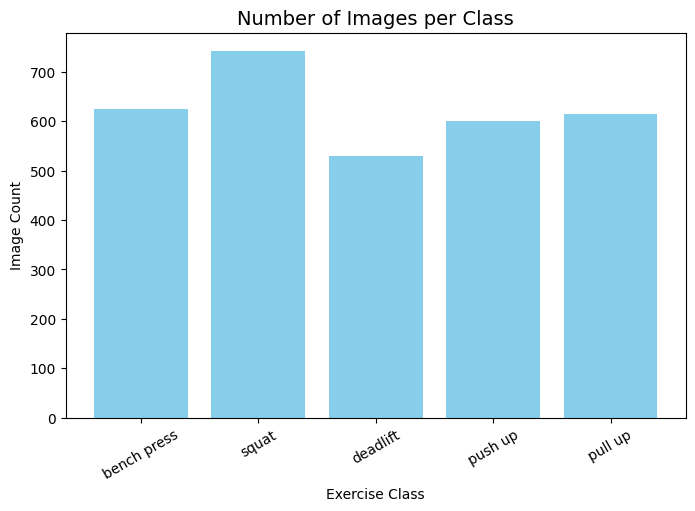

In [ ]:
# ====== EDA: Sample Images & Dataset Statistics ======
from collections import Counter
from PIL import Image

# Pick the 5 chosen classes
CHOSEN_CLASSES = ['bench press', 'squat', 'deadlift', 'push up', 'pull up']

# Count images in each chosen class
class_counts = {cls: len(list((DATA_ROOT/cls).glob("*.jpg"))) +
                      len(list((DATA_ROOT/cls).glob("*.jpeg"))) +
                      len(list((DATA_ROOT/cls).glob("*.png")))
                for cls in CHOSEN_CLASSES}

print("Image counts per chosen class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

# Plot bar chart of class distribution
plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values(), color="skyblue")
plt.title("Number of Images per Class", fontsize=14)
plt.xlabel("Exercise Class")
plt.ylabel("Image Count")
plt.xticks(rotation=30)
plt.show()

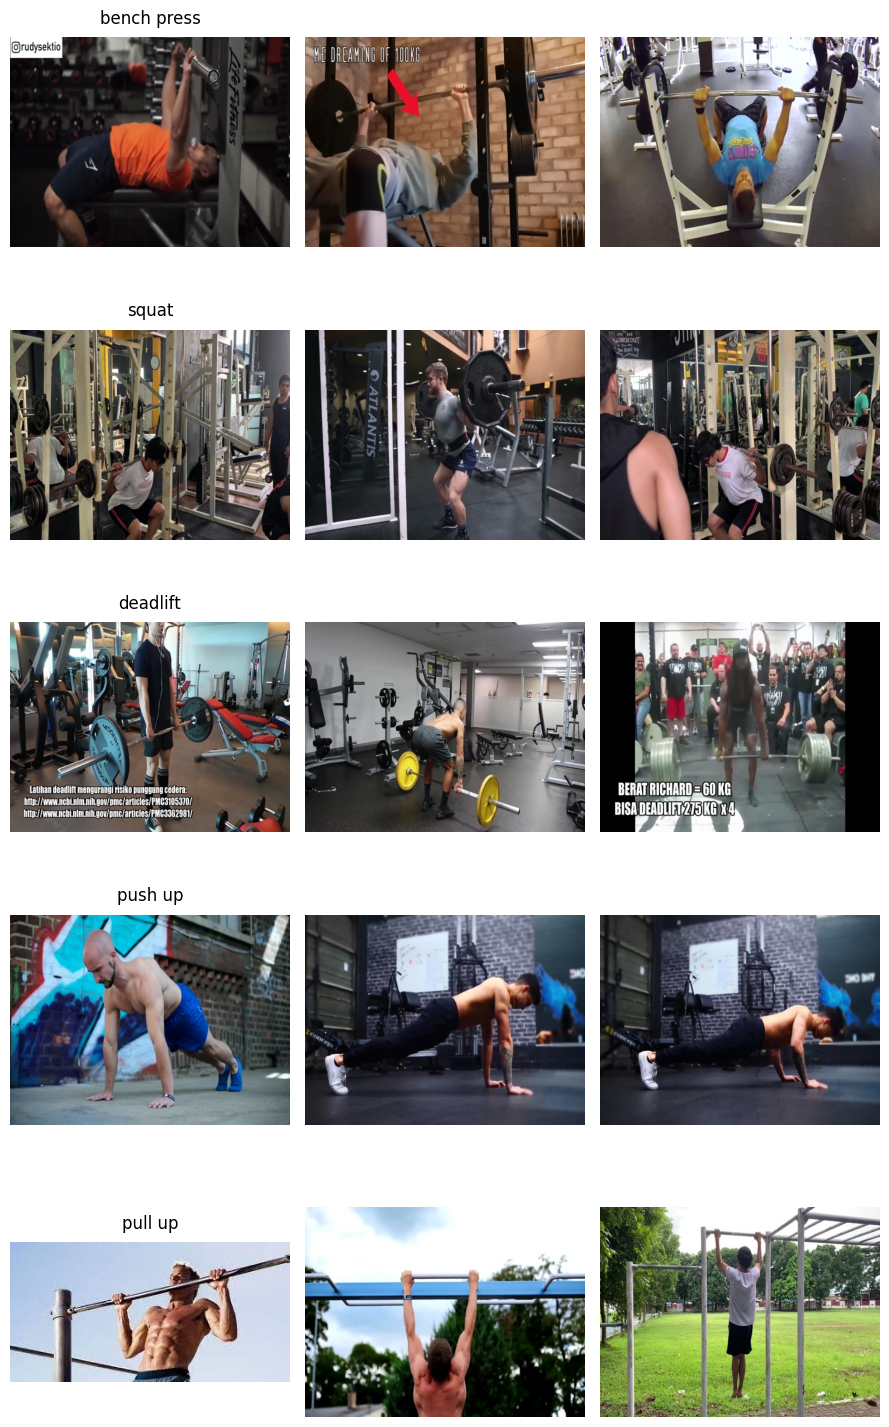

In [ ]:
# ====== Show random sample images from each class ======
def show_samples_per_class(root, classes, n_samples=3):
    fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples*3, len(classes)*3))
    for i, cls in enumerate(classes):
        img_paths = list((root/cls).glob("*.jpg")) + \
                    list((root/cls).glob("*.jpeg")) + \
                    list((root/cls).glob("*.png"))
        random.shuffle(img_paths)
        for j in range(n_samples):
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            img = Image.open(img_paths[j]).convert("RGB")
            ax.imshow(img)
            ax.axis("off")
            if j == 0:
                ax.set_title(cls, fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()

# Show 3 random samples per chosen class
show_samples_per_class(DATA_ROOT, CHOSEN_CLASSES, n_samples=3)

In [ ]:
# ====== Preprocessing, Normalization & Balanced Dataset ======
from torch.utils.data import Subset
import random

IMG_SIZE = 224
MAX_IMAGES_PER_CLASS = 500
BATCH_SIZE = 32

# Define transforms
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load dataset with torchvision
full_dataset = datasets.ImageFolder(DATA_ROOT, transform=train_tfms)

# Map class names
idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}
print("Class mapping:", idx_to_class)

Class mapping: {0: 'barbell biceps curl', 1: 'bench press', 2: 'chest fly machine', 3: 'deadlift', 4: 'decline bench press', 5: 'hammer curl', 6: 'hip thrust', 7: 'incline bench press', 8: 'lat pulldown', 9: 'lateral raises', 10: 'leg extension', 11: 'leg raises', 12: 'plank', 13: 'pull up', 14: 'push up', 15: 'romanian deadlift', 16: 'russian twist', 17: 'shoulder press', 18: 'squat', 19: 't bar row', 20: 'tricep dips', 21: 'tricep pushdown'}


In [ ]:
# Define transforms for train/val/test
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# Reload dataset but restrict to chosen classes only
all_data = datasets.ImageFolder(DATA_ROOT, transform=train_tfms)

# Filter indices so we only keep chosen classes
chosen_indices = [i for i, (_, y) in enumerate(all_data.samples)
                  if all_data.classes[y] in CHOSEN_CLASSES]

subset = Subset(all_data, chosen_indices)

# Re-map class_to_idx for chosen classes
class_to_idx = {cls: i for i, cls in enumerate(CHOSEN_CLASSES)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

# Update samples with remapped labels
subset.dataset.samples = [(fp, class_to_idx[all_data.classes[y]]) for fp, y in subset.dataset.samples if all_data.classes[y] in CHOSEN_CLASSES]

print("Class mapping:", class_to_idx)
print("Subset size:", len(subset))

Class mapping: {'bench press': 0, 'squat': 1, 'deadlift': 2, 'push up': 3, 'pull up': 4}
Subset size: 3113


In [ ]:
from collections import defaultdict
import random

# Group images by class
class_to_images = defaultdict(list)
for fp, label in subset.dataset.samples:
    if label in class_to_idx.values():
        class_to_images[label].append(fp)

# Balance dataset: take up to 500 per class
balanced_samples = []
MAX_PER_CLASS = 500
for cls, imgs in class_to_images.items():
    if len(imgs) >= MAX_PER_CLASS:
        selected = random.sample(imgs, MAX_PER_CLASS)
    else:
        selected = imgs  # use all if <500
    balanced_samples.extend([(fp, cls) for fp in selected])

print("Balanced dataset size:", len(balanced_samples))

Balanced dataset size: 2500


In [ ]:
from collections import defaultdict
import random

# Group images by class
class_to_images = defaultdict(list)
for fp, label in subset.dataset.samples:
    if label in class_to_idx.values():
        class_to_images[label].append(fp)

# Balance dataset: take up to 500 per class
balanced_samples = []
MAX_PER_CLASS = 500
for cls, imgs in class_to_images.items():
    if len(imgs) >= MAX_PER_CLASS:
        selected = random.sample(imgs, MAX_PER_CLASS)
    else:
        selected = imgs  # use all if <500
    balanced_samples.extend([(fp, cls) for fp in selected])

print("Balanced dataset size:", len(balanced_samples))

# Train/val/test split (70/15/15)
random.shuffle(balanced_samples)
n_total = len(balanced_samples)
n_train = int(0.7 * n_total)
n_val   = int(0.15 * n_total)

train_samples = balanced_samples[:n_train]
val_samples   = balanced_samples[n_train:n_train+n_val]
test_samples  = balanced_samples[n_train+n_val:]

print(f"Train={len(train_samples)}, Val={len(val_samples)}, Test={len(test_samples)}")

Balanced dataset size: 2500
Train=1750, Val=375, Test=375


In [ ]:
# Custom dataset wrapper
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        fp, label = self.samples[idx]
        img = Image.open(fp).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

# Final datasets
train_ds = CustomDataset(train_samples, transform=train_tfms)
val_ds   = CustomDataset(val_samples, transform=test_tfms)
test_ds  = CustomDataset(test_samples, transform=test_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

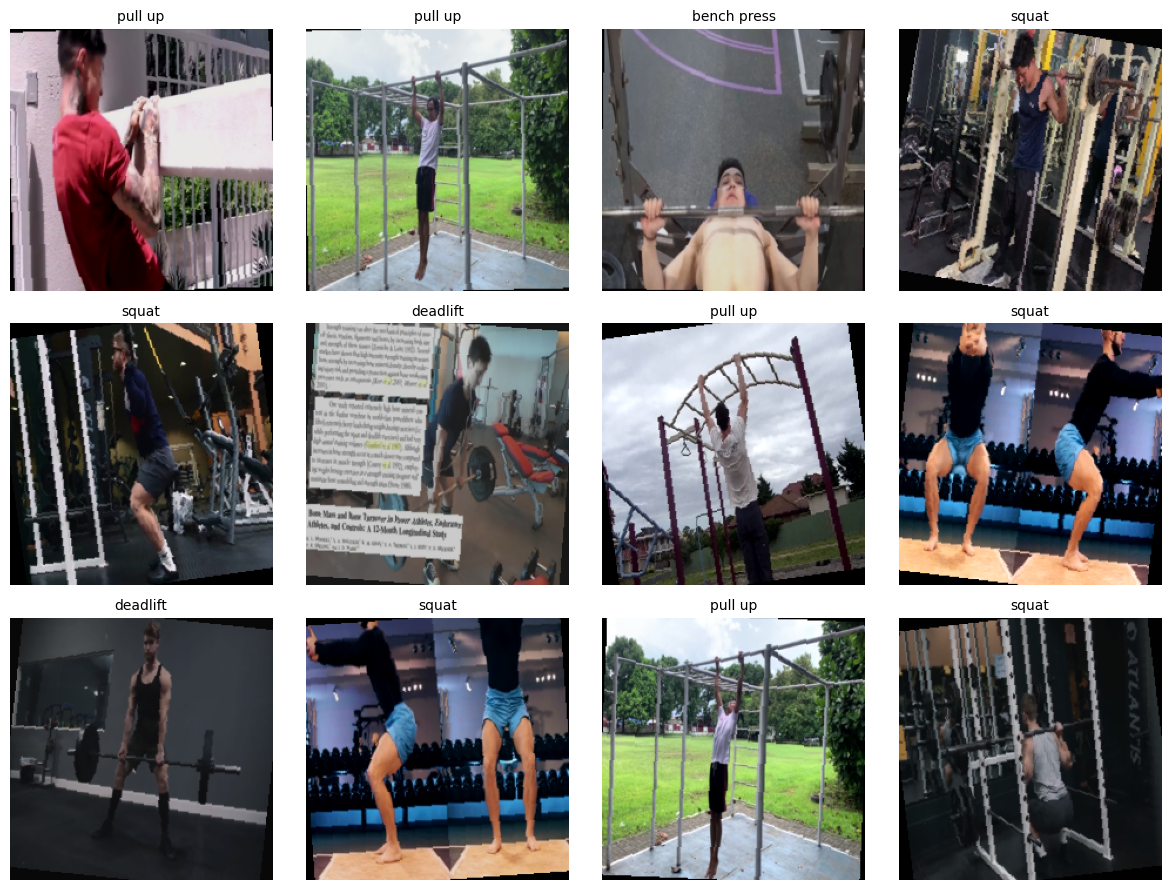

In [ ]:
# ====== Sanity Check: Visualize a Batch ======
import torchvision

def denormalize(img_tensor):
    """
    Undo ImageNet normalization for visualization
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img_tensor * std + mean

def show_batch(dataloader, n_images=16):
    # Grab one batch
    images, labels = next(iter(dataloader))

    # Denormalize for plotting
    images = [denormalize(img).permute(1,2,0).numpy() for img in images[:n_images]]
    labels = labels[:n_images]

    # Plot
    cols = 4
    rows = int(np.ceil(n_images / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < len(images):
            ax.imshow(np.clip(images[i], 0, 1))
            ax.set_title(idx_to_class[labels[i].item()], fontsize=10)
            ax.axis("off")
        else:
            ax.remove()
    plt.tight_layout()
    plt.show()

# ==== Run sanity check on training loader ====
show_batch(train_loader, n_images=12)

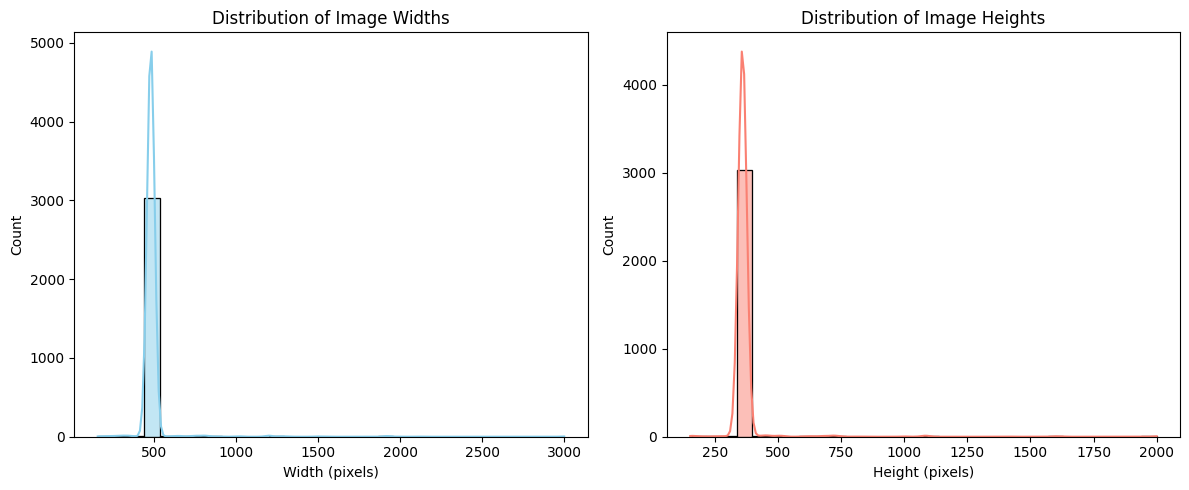

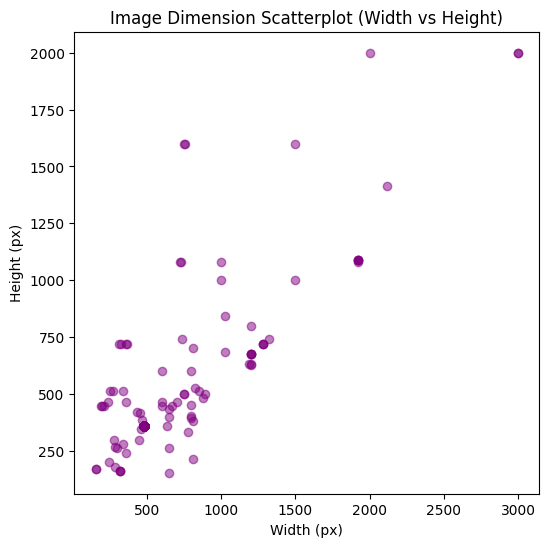

Average size: 490.0 × 367.9 pixels
Min size: 156 × 153 | Max size: 3000 × 2000


In [ ]:
# ====== EDA: Distribution of Original Image Sizes ======
import seaborn as sns
from PIL import Image

all_widths, all_heights = [], []

for cls in CHOSEN_CLASSES:
    img_paths = list((DATA_ROOT/cls).glob("*.jpg")) + \
                list((DATA_ROOT/cls).glob("*.jpeg")) + \
                list((DATA_ROOT/cls).glob("*.png"))
    for p in img_paths:
        try:
            with Image.open(p) as img:
                w, h = img.size
                all_widths.append(w)
                all_heights.append(h)
        except:
            continue  # skip unreadable images

# Plot distribution of widths and heights
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(all_widths, bins=30, color="skyblue", kde=True)
plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Count")

plt.subplot(1,2,2)
sns.histplot(all_heights, bins=30, color="salmon", kde=True)
plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Scatter plot of width vs height
plt.figure(figsize=(6,6))
plt.scatter(all_widths, all_heights, alpha=0.5, c="purple")
plt.title("Image Dimension Scatterplot (Width vs Height)")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.show()

print(f"Average size: {np.mean(all_widths):.1f} × {np.mean(all_heights):.1f} pixels")
print(f"Min size: {np.min(all_widths)} × {np.min(all_heights)} | Max size: {np.max(all_widths)} × {np.max(all_heights)}")

In [ ]:
# ====== Model Training & Evaluation ======
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from copy import deepcopy

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load EfficientNet-B0 pretrained
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, len(CHOSEN_CLASSES))
)
model = model.to(DEVICE)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
# ====== Show Model Architecture ======
from torchsummary import summary

# Print full architecture
print(model)

# Print layer-wise summary (input 3x224x224)
summary(model, (3, 224, 224))

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# ====== Training Loop ======
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_acc, best_state = 0.0, None
EPOCHS = 5

for epoch in range(1, EPOCHS+1):
    # ---- Training ----
    model.train()
    correct, total, train_loss = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * yb.size(0)
        preds = outputs.argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    train_acc = correct / total
    train_loss /= total

    # ---- Validation ----
    model.eval()
    correct, total, val_loss = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item() * yb.size(0)
            preds = outputs.argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    val_acc = correct / total
    val_loss /= total

    # Save history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}: Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}, "
          f"Train Loss={train_loss:.3f}, Val Loss={val_loss:.3f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_state = deepcopy(model.state_dict())

    scheduler.step()

Epoch 01: Train Acc=0.991, Val Acc=0.997, Train Loss=0.034, Val Loss=0.012
Epoch 02: Train Acc=0.997, Val Acc=0.997, Train Loss=0.021, Val Loss=0.011
Epoch 03: Train Acc=0.999, Val Acc=0.997, Train Loss=0.008, Val Loss=0.013
Epoch 04: Train Acc=1.000, Val Acc=0.997, Train Loss=0.004, Val Loss=0.012
Epoch 05: Train Acc=0.998, Val Acc=0.997, Train Loss=0.007, Val Loss=0.007


In [ ]:
# Load best model
model.load_state_dict(best_state)

<All keys matched successfully>

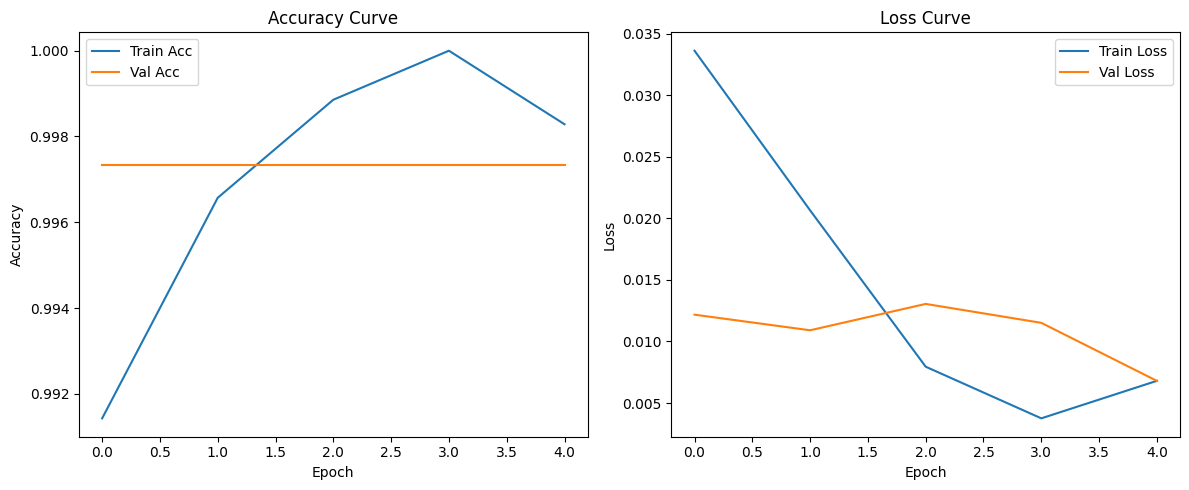

In [ ]:
# ====== Accuracy & Loss Curves ======
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss Curve")

plt.tight_layout()
plt.show()

In [ ]:
# ====== Test Evaluation ======
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        outputs = model(xb)
        preds = outputs.argmax(1)
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Accuracy
test_acc = np.mean(np.array(y_true) == np.array(y_pred))
print(f"\n Test Accuracy: {test_acc*100:.2f}%")


 Test Accuracy: 99.73%


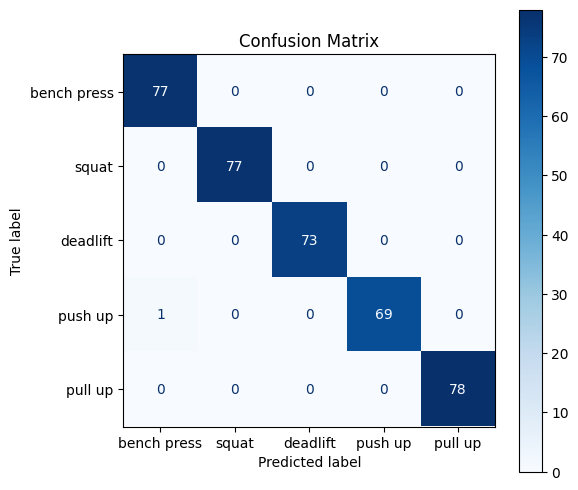

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CHOSEN_CLASSES)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Confusion Matrix")
plt.show()

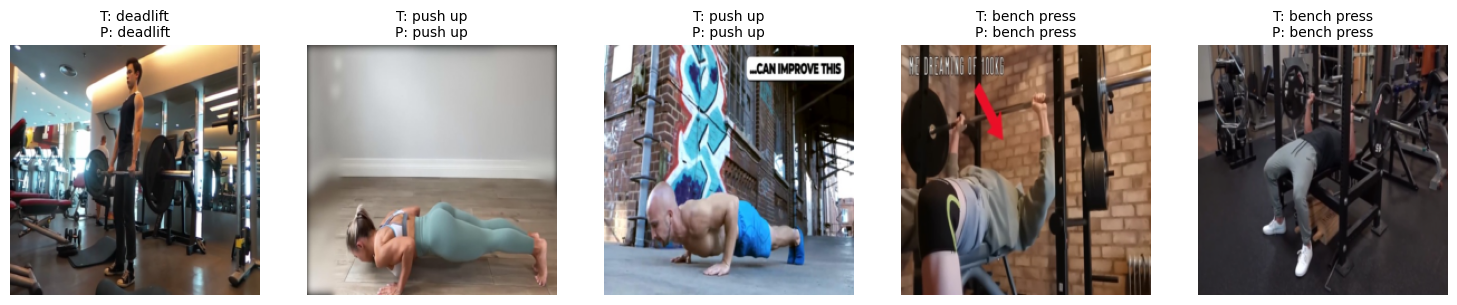

In [ ]:
# ====== Test on Random Images ======
import random
from PIL import Image

def test_random_images(n=5):
    fig, axes = plt.subplots(1, n, figsize=(n*3, 3))
    if n == 1: axes = [axes]
    for i in range(n):
        # pick random test sample
        idx = random.choice(range(len(test_ds)))
        img, label = test_ds[idx]
        true_cls = idx_to_class[label]

        # predict
        model.eval()
        with torch.no_grad():
            output = model(img.unsqueeze(0).to(DEVICE))
            pred_cls = idx_to_class[output.argmax(1).item()]

        # show
        axes[i].imshow(denormalize(img).permute(1,2,0).numpy())
        axes[i].set_title(f"T: {true_cls}\nP: {pred_cls}", fontsize=10)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

# Show 5 random test images with actual vs predicted
test_random_images(n=5)

In [ ]:
import torch

# Save entire model
torch.save(model, "exercise_classifier.pth")

# OR save only the state dict (recommended)
torch.save(model.state_dict(), "exercise_classifier_state.pth")

print("Model saved successfully!")

Model saved successfully!
